#  Demand Forecasting

### Objective
This notebook focuses on forecasting future retail sales using Time Series Analysis. It includes data resampling, trend analysis, seasonality, decomposition, ACF plot, ARIMA model, Prophet model, and evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [2]:
df = pd.read_csv("../../member 1/cleaned_data/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [3]:
daily_sales = (
    df.groupby("InvoiceDate")["TotalAmount"]
    .sum()
    .resample("D")
    .sum()
)

daily_sales.head()

InvoiceDate
2009-12-01    43894.87
2009-12-02    52762.06
2009-12-03    67413.62
2009-12-04    33913.81
2009-12-05     9803.05
Freq: D, Name: TotalAmount, dtype: float64

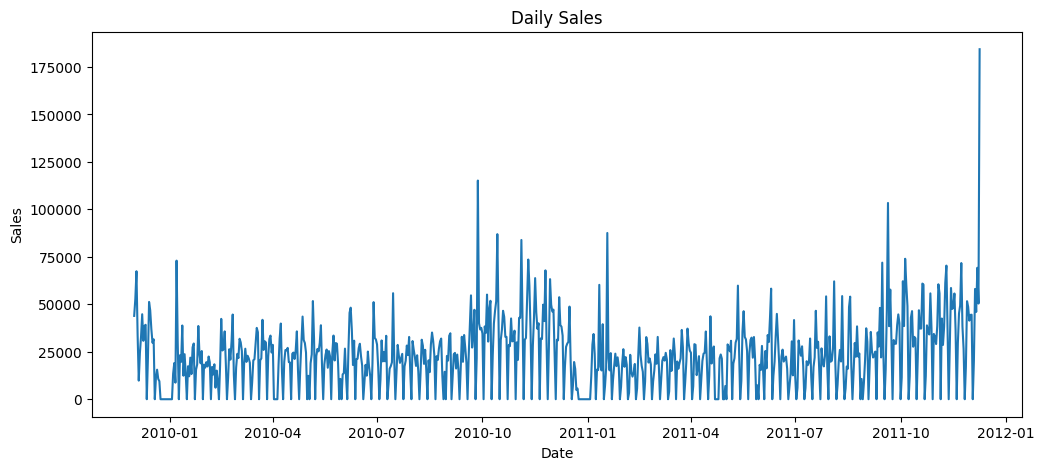

In [4]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

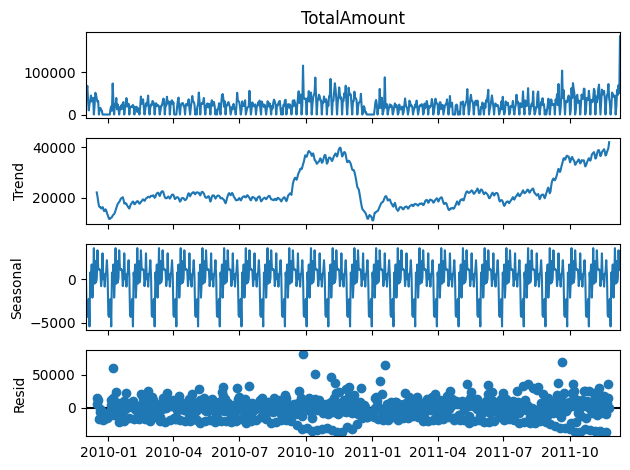

In [5]:
decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=30
)

decomposition.plot()

plt.show()

<Figure size 1000x400 with 0 Axes>

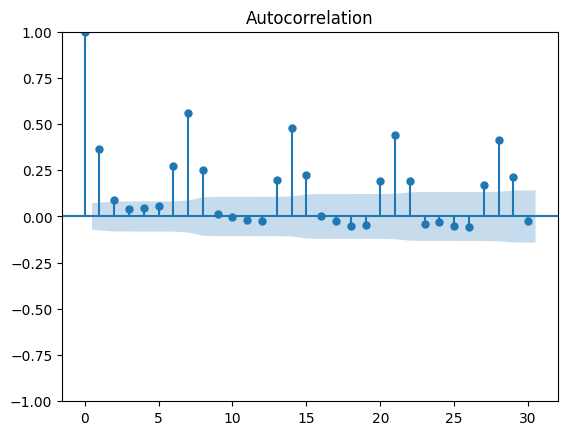

In [6]:
plt.figure(figsize=(10,4))

plot_acf(daily_sales.dropna(), lags=30)

plt.show()

In [9]:
# ARIMA Model
from sklearn.model_selection import train_test_split

train = daily_sales[:-30]
test = daily_sales[-30:]

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

forecast

2011-11-10    56610.486931
2011-11-11    29487.791774
2011-11-12    37211.711807
2011-11-13    37869.595133
2011-11-14    38397.006134
2011-11-15    46535.145053
2011-11-16    49753.132776
2011-11-17    39815.917143
2011-11-18    38825.130206
2011-11-19    40058.442401
2011-11-20    40117.651902
2011-11-21    42413.664282
2011-11-22    45041.589340
2011-11-23    42271.980092
2011-11-24    40608.304524
2011-11-25    40877.297013
2011-11-26    41033.185221
2011-11-27    41594.728579
2011-11-28    42864.493633
2011-11-29    42386.760964
2011-11-30    41479.337192
2011-12-01    41337.190276
2011-12-02    41428.065343
2011-12-03    41559.555440
2011-12-04    42055.255593
2011-12-05    42105.627198
2011-12-06    41759.027915
2011-12-07    41587.333873
2011-12-08    41602.342803
2011-12-09    41634.281851
Freq: D, Name: predicted_mean, dtype: float64

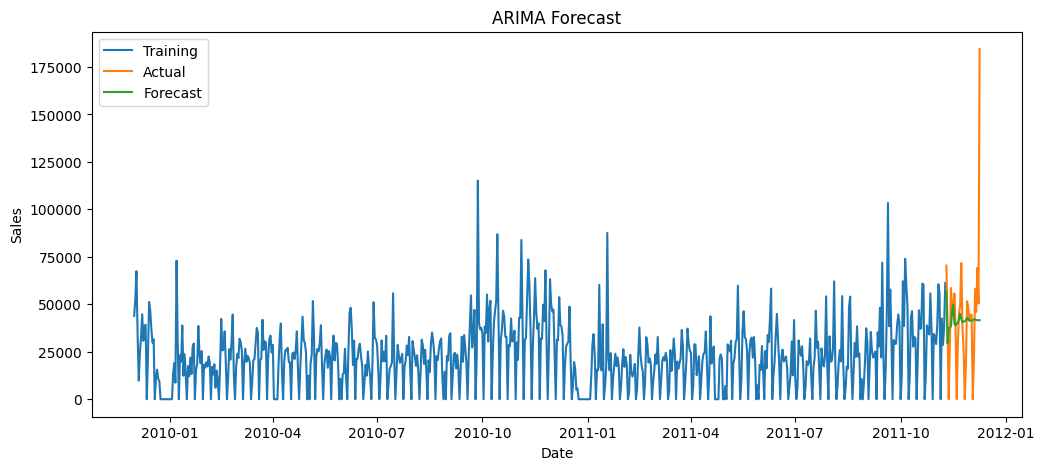

In [10]:
# Forecast Graph
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [12]:
# RMSE & MAPE
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print("RMSE :", rmse)
print("MAPE :", mape)

RMSE : 32309.357562261663
MAPE : 2.399861579212369e+19


09:28:43 - cmdstanpy - INFO - Chain [1] start processing
09:28:48 - cmdstanpy - INFO - Chain [1] done processing


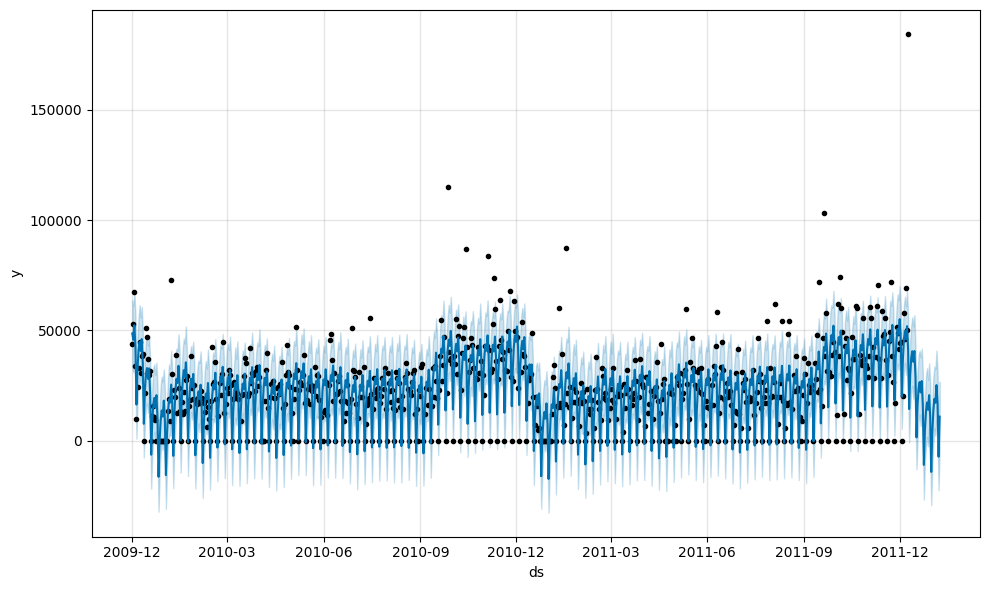

In [14]:
# Prophet
from prophet import Prophet
prophet_df = daily_sales.reset_index()
prophet_df.columns = ["ds", "y"]

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

model.plot(forecast)

plt.show()

In [15]:
print("Demand Forecasting Completed Successfully!")

print("\nTasks Completed:")
print("✔ Daily Sales")
print("✔ Time Series Decomposition")
print("✔ Trend")
print("✔ Seasonality")
print("✔ Residual")
print("✔ ACF Plot")
print("✔ ARIMA Forecast")
print("✔ RMSE")
print("✔ MAPE")

Demand Forecasting Completed Successfully!

Tasks Completed:
✔ Daily Sales
✔ Time Series Decomposition
✔ Trend
✔ Seasonality
✔ Residual
✔ ACF Plot
✔ ARIMA Forecast
✔ RMSE
✔ MAPE
